# Test LegNet Model Loading & Prediction
Quick sanity check using the example model/fasta from the human_legnet repo.

In [76]:
import sys
sys.path.insert(0, '../../human_legnet')

import torch
import lightning.pytorch as pl
from trainer import LitModel, TrainingConfig
from fasta import FastaDataset
from torch.utils.data import DataLoader

In [77]:
# Paths — use K562 pretrained models from Zenodo
REPO_ROOT = '../../human_legnet'
K562_MODEL_DIR = '../../.weights/legnet_pretrained/final_dump/models/K562/md_shift_reverse_noavg_noch'
CONFIG_PATH = f'{K562_MODEL_DIR}/config.json'

In [78]:
# Load config and 10 K562 models (one per test fold)
import glob

train_cfg = TrainingConfig.from_json(CONFIG_PATH)

# Pick one checkpoint per test fold (first available val fold)
models = []
for test_fold in range(1, 11):
    pattern = f'{K562_MODEL_DIR}/best_model_test{test_fold}_val*.ckpt'
    cp = sorted(glob.glob(pattern))[0]  # first available val fold
    m = LitModel.load_from_checkpoint(cp, tr_cfg=train_cfg)
    m.eval()
    m.model.cuda()
    models.append(m.model)
    print(f'  Loaded {cp.split("/")[-1]}')

print(f'\n{len(models)} models loaded (10-fold ensemble)')

  Loaded best_model_test1_val10.ckpt
  Loaded best_model_test2_val1.ckpt
  Loaded best_model_test3_val1.ckpt
  Loaded best_model_test4_val1.ckpt
  Loaded best_model_test5_val1.ckpt
  Loaded best_model_test6_val1.ckpt
  Loaded best_model_test7_val1.ckpt
  Loaded best_model_test8_val1.ckpt
  Loaded best_model_test9_val1.ckpt
  Loaded best_model_test10_val1.ckpt

10 models loaded (10-fold ensemble)


In [89]:
# Load K562 data — same filtering as AGFT: rev==0, fold==[10] (test split)
import pandas as pd
from utils import encode_seq

k562 = pd.read_csv(f'{REPO_ROOT}/datasets/original/K562.tsv', sep='\t')
k562 = k562[k562['rev'] == 0].reset_index(drop=True)
test_data = k562[k562['fold'] == 10].reset_index(drop=True)
print(f'Test set: {len(test_data)} sequences')

# Use idx 9113 — same as AGFT interpreting notebook
SEQ_IDX = 6277
row = test_data.iloc[SEQ_IDX]
seq_str = row['seq']
seq_name = row['seq_id']
seq_onehot = encode_seq(seq_str)  # (4, seq_len)
seq_len = seq_onehot.shape[1]
print(f'idx={SEQ_IDX}: {seq_name}, length={seq_len}, activity={row["mean_value"]:.3f}')

Test set: 19670 sequences
idx=6277: peak39489_Reversed:, length=230, activity=2.838


In [90]:
# Ensemble prediction across all 10 folds
import numpy as np

with torch.no_grad():
    x = seq_onehot.unsqueeze(0).cuda()
    wt_preds = [m(x).item() for m in models]
wt_pred = np.mean(wt_preds)
print(f'Ensemble WT prediction: {wt_pred:.4f} (std={np.std(wt_preds):.4f})')
print(f'Actual activity: {row["mean_value"]:.4f}')

Ensemble WT prediction: 2.2380 (std=0.3395)
Actual activity: 2.8380


In [91]:
# ISM with 10-fold ensemble — ACGT, per-position mean centered
from utils import CODES

bases = ['A', 'C', 'G', 'T']

# Create all mutants in ACGT order
all_mutants = []
for pos in range(seq_len):
    for base in bases:
        mut = seq_onehot.clone()
        mut[:, pos] = 0
        mut[CODES[base], pos] = 1
        all_mutants.append(mut)
all_mutants = torch.stack(all_mutants).cuda()
print(f'Total mutants: {all_mutants.shape[0]}')

# Predict with each model, average
batch_size = 512
ensemble_preds = []
with torch.no_grad():
    for mi, m in enumerate(models):
        preds = []
        for i in range(0, len(all_mutants), batch_size):
            pred = m(all_mutants[i:i+batch_size]).cpu().numpy().flatten()
            preds.append(pred)
        ensemble_preds.append(np.concatenate(preds))

# Raw predictions per base per position, averaged across models
avg_preds = np.mean(ensemble_preds, axis=0).reshape(seq_len, 4)  # (seq_len, 4) ACGT

# Center by subtracting per-position mean (same as AGFT compute_ism_attributions)
pos_means = avg_preds.mean(axis=1, keepdims=True)  # (seq_len, 1)
ism_scores = avg_preds - pos_means
print('Done!')

Total mutants: 920
Done!


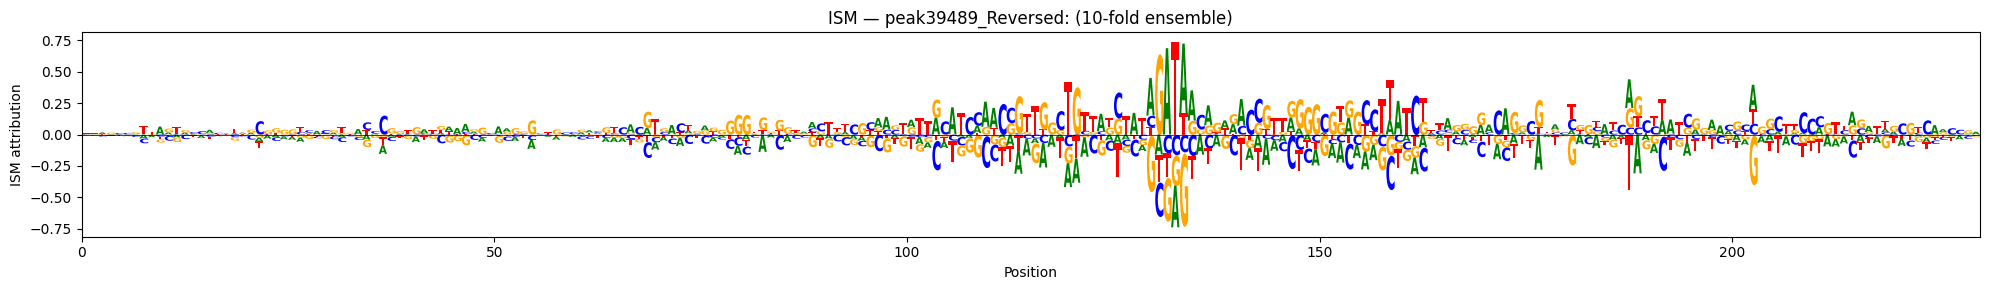

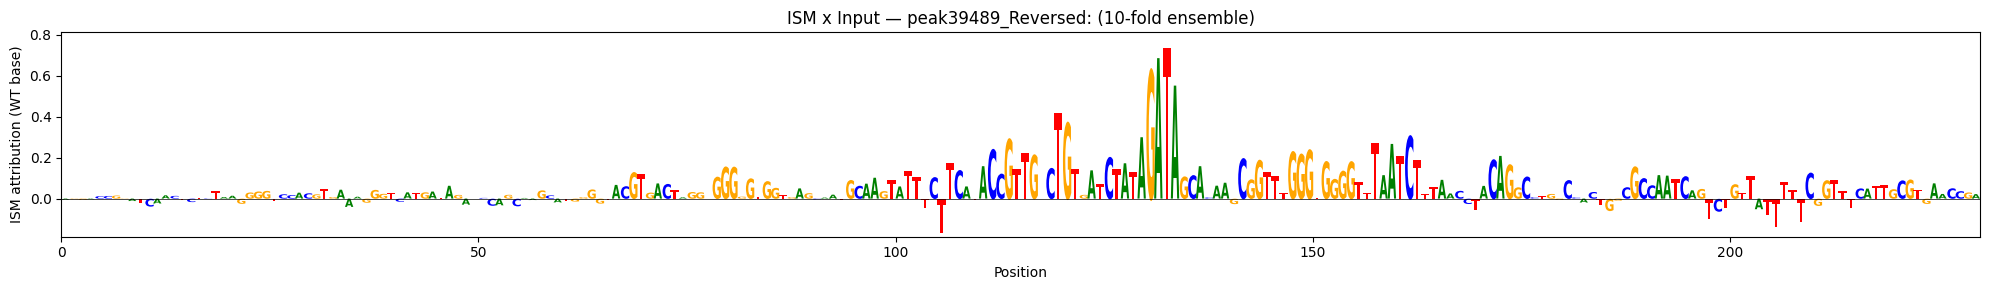

In [92]:
import matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

COLORS = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
fp = FontProperties(family='DejaVu Sans', weight='bold')

def draw_letter(letter, x, y, height, ax, color):
    tp = TextPath((0, 0), letter, size=1, prop=fp)
    bb = tp.get_extents()
    sx = 1.0 / (bb.width if bb.width > 0 else 1)
    sy = abs(height) / (bb.height if bb.height > 0 else 1)
    tp_t = tp.transformed(Affine2D().scale(sx, sy).translate(x, y))
    ax.add_patch(PathPatch(tp_t, facecolor=color, edgecolor='none'))

def plot_logo(scores_matrix, title, ylabel):
    fig, ax = plt.subplots(figsize=(20, 3))
    for pos in range(scores_matrix.shape[0]):
        scores = scores_matrix[pos]
        pos_items = sorted([(scores[i], bases[i]) for i in range(4) if scores[i] > 0], key=lambda x: x[0])
        y = 0
        for score, base in pos_items:
            draw_letter(base, pos, y, score, ax, COLORS[base])
            y += score
        neg_items = sorted([(scores[i], bases[i]) for i in range(4) if scores[i] < 0], key=lambda x: -x[0])
        y = 0
        for score, base in neg_items:
            draw_letter(base, pos, y + score, abs(score), ax, COLORS[base])
            y += score
    ymax = scores_matrix.clip(0).sum(axis=1).max() * 1.1 + 0.001
    ymin = scores_matrix.clip(max=0).sum(axis=1).min() * 1.1 - 0.001
    ax.set_xlim(0, scores_matrix.shape[0])
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Position')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Full ISM logo (all bases)
plot_logo(ism_scores, f'ISM — {seq_name} (10-fold ensemble)', 'ISM attribution')

# ISM x OneHot (WT base only) — same as AGFT: attr * seq
wt_onehot = np.zeros((seq_len, 4))
for i, nt in enumerate(seq_str):
    wt_onehot[i, bases.index(nt)] = 1
ism_wt = ism_scores * wt_onehot
plot_logo(ism_wt, f'ISM x Input — {seq_name} (10-fold ensemble)', 'ISM attribution (WT base)')